# Training Analysis — Gradient Diagnostics

Sandbox notebook for analyzing the training procedure in depth.
All training-critical code is inlined (cell setup, loss, training loop, parameter transforms)
so it can be directly inspected and tweaked.

**Key features:**
- Per-parameter gradient tracking across full training runs
- One-shot gradient inspection at any parameter configuration
- Parameter trajectory visualization with ground truth reference
- Loss decomposition by feature

In [20]:
import logging
import time
from dataclasses import dataclass, field
from pathlib import Path

import jax
import jax.numpy as jnp
import jax.random as jr
import jaxley as jx
import matplotlib.pyplot as plt
import numpy as np
import optax
from jax import Array, config
from jaxley.channels import AdExSurrogate

# ADoptEX: only for data I/O, evaluation, and plotting utilities
from ADoptEX.core.data import TraceData, crop_to_stim_window, load_trace
from ADoptEX.core.simulation import SimulationResult, simulate_with_current_trace
from ADoptEX.evaluation.coincidence import coincidence_factor
from ADoptEX.loss import VanRossumLossConfig, make_van_rossum_loss_fn
from ADoptEX.plotting import fit_comparison_plot, trace_stim_window_plot

config.update("jax_platform_name", "cpu")
logging.basicConfig(level=logging.INFO, format="%(message)s")
log = logging.getLogger(__name__)

SEED = 42

## 1. Parameter Definitions & Bounds (inlined)

In [21]:
@dataclass
class ParamBounds:
    min: float
    max: float
    def clip(self, value: float) -> float:
        return max(self.min, min(self.max, value))

PARAM_BOUNDS: dict[str, ParamBounds] = {
    "C_m": ParamBounds(10.0, 240.0),
    "capacitance": ParamBounds(180.0, 220.0),
    "g_L": ParamBounds(6.0, 14.0),
    "E_L": ParamBounds(-110.0, -65.0),
    "v_T": ParamBounds(-60.0, -35.0),
    "delta_T": ParamBounds(1, 20.0),
    "v_reset": ParamBounds(-80.0, -45.0),
    "v_threshold": ParamBounds(-20.0, 30.0),
    "tau_w": ParamBounds(20.0, 320.0),
    "a": ParamBounds(-10.0, 3.0),
    "b": ParamBounds(0.0, 65.0),
}

NAUD_PARAMETERS = {
    "tonic": {
        "C_m": 200.0, "g_L": 10.0, "E_L": -70.0, "v_T": -50.0,
        "delta_T": 2.0, "v_reset": -58.0, "v_threshold": 0.0,
        "tau_w": 30.0, "a": 2.0, "b": 0.0, "I": 500.0,
    },
    "adaptation": {
        "C_m": 200.0, "g_L": 12.0, "E_L": -70.0, "v_T": -50.0,
        "delta_T": 2.0, "v_reset": -58.0, "v_threshold": 0.0,
        "tau_w": 300.0, "a": 2.0, "b": 60.0, "I": 500.0,
    },
}

## 2. Cell Creation & Simulation (inlined)

In [22]:
# Fixed geometry for point-neuron mode (area = 100 um²)
# With area=100: I_nA / 100 * 1e5 = I_pA → dv/dt = I_pA / C_m [mV/ms]
POINT_NEURON_RADIUS_UM = 1.0
POINT_NEURON_LENGTH_UM = 50.0 / np.pi  # area = 2π·1·50/π = 100 um²


def create_adex_cell(
    params: dict,
    surrogate_type: str = "sigmoid",
    surrogate_slope: float = 5.0,
    trainable: bool = False,
    trainable_params: list[str] | None = None,
) -> jx.Cell:
    """Create a Jaxley cell with AdExSurrogate channel."""
    cell = jx.Cell()
    cell.set("radius", POINT_NEURON_RADIUS_UM)
    cell.set("length", POINT_NEURON_LENGTH_UM)

    cell.insert(AdExSurrogate(
        surrogate_type=surrogate_type,
        surrogate_slope=surrogate_slope,
    ))

    cell.set("capacitance", params["C_m"])
    for name in ["g_L", "E_L", "v_T", "delta_T", "v_threshold", "v_reset", "tau_w", "a", "b"]:
        cell.set(f"AdEx_{name}", params[name])
    cell.set("v", params["E_L"])

    cell.record("v")
    cell.record("AdEx_w")
    cell.record("AdEx_spikes")

    if trainable:
        if trainable_params is None:
            trainable_params = ["C_m", "g_L", "E_L", "v_T", "v_reset", "tau_w", "a", "b"]
        for p in trainable_params:
            cell.make_trainable("capacitance" if p == "C_m" else f"AdEx_{p}")

    return cell


def setup_trainable_cell(
    initial_params: dict,
    current_trace_pA: np.ndarray,
    dt_ms: float,
    trainable_params: list[str],
    surrogate_type: str = "sigmoid",
    surrogate_slope: float = 5.0,
) -> tuple:
    """Create cell with data stimulation and trainable params. Returns (cell, data_stimuli, t_max, params)."""
    cell = create_adex_cell(
        initial_params,
        surrogate_type=surrogate_type,
        surrogate_slope=surrogate_slope,
        trainable=True,
        trainable_params=trainable_params,
    )
    current_nA = jnp.array(current_trace_pA / 1000.0)
    data_stimuli = cell.comp(0).data_stimulate(current_nA, None)
    t_max = len(current_trace_pA) * dt_ms
    return cell, data_stimuli, t_max, cell.get_parameters()

## 3. Guarino Loss Function (inlined)

In [23]:
# --- Soft feature primitives ---

def soft_spike_count(spike_trace: Array) -> Array:
    return jnp.sum(spike_trace)

def soft_time_to_nth_spike(spike_trace, n, dt_ms, temperature=0.1, beta=10.0):
    T = len(spike_trace)
    time_indices = jnp.arange(T) * dt_ms
    cumsum = jnp.cumsum(spike_trace)
    lower_mask = jax.nn.sigmoid(beta * (cumsum - (n - 0.5)))
    upper_mask = jax.nn.sigmoid(beta * (cumsum - (n + 0.5)))
    weights = spike_trace * (lower_mask - upper_mask)
    weights_sharp = jnp.power(weights + 1e-10, 1.0 / temperature)
    weight_sum = jnp.sum(weights_sharp)
    weights_normalized = weights_sharp / (weight_sum + 1e-10)
    return jnp.sum(time_indices * weights_normalized)

def soft_time_to_last_spike(spike_trace, dt_ms, temperature=0.1, beta=10.0):
    T = len(spike_trace)
    time_indices = jnp.arange(T) * dt_ms
    reverse_cumsum = jnp.cumsum(spike_trace[::-1])[::-1]
    last_spike_mask = (
        jax.nn.sigmoid(beta * (reverse_cumsum - 0.5))
        - jax.nn.sigmoid(beta * (reverse_cumsum - 1.5))
    ) * spike_trace
    weights_sharp = jnp.power(last_spike_mask + 1e-10, 1.0 / temperature)
    weight_sum = jnp.sum(weights_sharp)
    return jnp.sum(time_indices * weights_sharp / (weight_sum + 1e-10))

def soft_time_to_second_last_spike(spike_trace, dt_ms, temperature=0.1, beta=10.0):
    T = len(spike_trace)
    time_indices = jnp.arange(T) * dt_ms
    reverse_cumsum = jnp.cumsum(spike_trace[::-1])[::-1]
    mask = (
        jax.nn.sigmoid(beta * (reverse_cumsum - 1.5))
        - jax.nn.sigmoid(beta * (reverse_cumsum - 2.5))
    ) * spike_trace
    weights_sharp = jnp.power(mask + 1e-10, 1.0 / temperature)
    weight_sum = jnp.sum(weights_sharp)
    return jnp.sum(time_indices * weights_sharp / (weight_sum + 1e-10))

def soft_inverse_first_isi(spike_trace, dt_ms, temperature=0.1, beta=10.0, epsilon=1e-6):
    t1 = soft_time_to_nth_spike(spike_trace, 1, dt_ms, temperature, beta)
    t2 = soft_time_to_nth_spike(spike_trace, 2, dt_ms, temperature, beta)
    return 1.0 / jnp.maximum(t2 - t1, epsilon)

def soft_inverse_last_isi(spike_trace, dt_ms, temperature=0.1, beta=10.0, epsilon=1e-6):
    t_last = soft_time_to_last_spike(spike_trace, dt_ms, temperature, beta)
    t_second_last = soft_time_to_second_last_spike(spike_trace, dt_ms, temperature, beta)
    return 1.0 / jnp.maximum(t_last - t_second_last, epsilon)

def soft_firing_frequency(spike_trace, stim_duration_ms):
    return jnp.sum(spike_trace) / (stim_duration_ms / 1000.0)


# --- Feature container ---

@dataclass
class GuarinoFeatures:
    t_first_spike: Array
    t_second_spike: Array
    t_third_spike: Array
    t_last_spike: Array
    inv_first_isi: Array
    inv_last_isi: Array
    firing_frequency: Array
    v_stim_end: Array
    has_first_spike: Array
    has_second_spike: Array
    has_third_spike: Array
    n_spikes: Array


# --- Feature extractor ---

class GuarinoFeatureExtractor:
    def __init__(self, dt_ms, stim_duration_ms, stim_end_index, temperature=0.1, beta=10.0):
        self.dt_ms = dt_ms
        self.stim_duration_ms = stim_duration_ms
        self.stim_end_index = stim_end_index
        self.temperature = temperature
        self.beta = beta

    def extract(self, voltage_trace, spike_trace) -> GuarinoFeatures:
        n_spikes = soft_spike_count(spike_trace)
        validity_beta = 10.0
        has_first = jax.nn.sigmoid(validity_beta * (n_spikes - 0.5))
        has_second = jax.nn.sigmoid(validity_beta * (n_spikes - 1.5))
        has_third = jax.nn.sigmoid(validity_beta * (n_spikes - 2.5))

        kw = dict(dt_ms=self.dt_ms, temperature=self.temperature, beta=self.beta)
        t_first = soft_time_to_nth_spike(spike_trace, 1, **kw)
        t_second = soft_time_to_nth_spike(spike_trace, 2, **kw)
        t_third = soft_time_to_nth_spike(spike_trace, 3, **kw)
        t_last = soft_time_to_last_spike(spike_trace, **kw)
        inv_first = soft_inverse_first_isi(spike_trace, **kw)
        inv_last = soft_inverse_last_isi(spike_trace, **kw)
        freq = soft_firing_frequency(spike_trace, self.stim_duration_ms)
        safe_idx = jnp.minimum(self.stim_end_index, len(voltage_trace) - 1)
        v_end = voltage_trace[safe_idx]

        return GuarinoFeatures(
            t_first_spike=t_first, t_second_spike=t_second, t_third_spike=t_third,
            t_last_spike=t_last, inv_first_isi=inv_first, inv_last_isi=inv_last,
            firing_frequency=freq, v_stim_end=v_end,
            has_first_spike=has_first, has_second_spike=has_second, has_third_spike=has_third,
            n_spikes=n_spikes,
        )


# --- Loss config ---

@dataclass
class GuarinoLossConfig:
    weight_t_first: float = 1.0
    weight_t_second: float = 1.0
    weight_t_third: float = 1.0
    weight_t_last: float = 1.0
    weight_inv_first_isi: float = 1.0
    weight_inv_last_isi: float = 1.0
    weight_firing_freq: float = 1.0
    weight_v_stim_end: float = 1.0
    weight_spike_count: float = 0.0
    missing_feature_penalty: float = 3.0
    epsilon: float = 1e-6


# --- Loss computation ---

def relative_error(sim_value, exp_value, epsilon=1e-6):
    return jnp.abs(sim_value - exp_value) / (jnp.abs(exp_value) + epsilon)


def guarino_loss(sim_features, exp_features, config=None):
    if config is None:
        config = GuarinoLossConfig()
    total = jnp.array(0.0)
    eps = config.epsilon
    penalty = config.missing_feature_penalty

    # Per-feature losses (returned separately for decomposition)
    for name, weight, sim_val, exp_val, sim_valid, exp_valid in [
        ("t_first", config.weight_t_first, sim_features.t_first_spike, exp_features.t_first_spike, sim_features.has_first_spike, exp_features.has_first_spike),
        ("t_second", config.weight_t_second, sim_features.t_second_spike, exp_features.t_second_spike, sim_features.has_second_spike, exp_features.has_second_spike),
        ("t_third", config.weight_t_third, sim_features.t_third_spike, exp_features.t_third_spike, sim_features.has_third_spike, exp_features.has_third_spike),
    ]:
        err = relative_error(sim_val, exp_val, eps)
        pen = penalty * jnp.maximum(0.0, exp_valid - sim_valid)
        total = total + weight * (sim_valid * exp_valid * err + pen)

    # t_last
    err_last = relative_error(sim_features.t_last_spike, exp_features.t_last_spike, eps)
    total = total + config.weight_t_last * sim_features.has_first_spike * exp_features.has_first_spike * err_last

    # ISIs (need >= 2 spikes)
    for weight, sim_val, exp_val in [
        (config.weight_inv_first_isi, sim_features.inv_first_isi, exp_features.inv_first_isi),
        (config.weight_inv_last_isi, sim_features.inv_last_isi, exp_features.inv_last_isi),
    ]:
        err = relative_error(sim_val, exp_val, eps)
        total = total + weight * sim_features.has_second_spike * exp_features.has_second_spike * err

    # Firing frequency (always)
    total = total + config.weight_firing_freq * relative_error(sim_features.firing_frequency, exp_features.firing_frequency, eps)

    # v_stim_end (always)
    total = total + config.weight_v_stim_end * relative_error(sim_features.v_stim_end, exp_features.v_stim_end, eps)

    # Spike count penalty
    if config.weight_spike_count > 0:
        total = total + config.weight_spike_count * (sim_features.n_spikes - exp_features.n_spikes) ** 2

    return total


def guarino_loss_decomposed(sim_features, exp_features, config=None):
    """Return per-feature loss breakdown as a dict (for analysis)."""
    if config is None:
        config = GuarinoLossConfig()
    eps = config.epsilon
    penalty = config.missing_feature_penalty
    losses = {}

    for name, weight, sim_val, exp_val, sim_v, exp_v in [
        ("t_first", config.weight_t_first, sim_features.t_first_spike, exp_features.t_first_spike, sim_features.has_first_spike, exp_features.has_first_spike),
        ("t_second", config.weight_t_second, sim_features.t_second_spike, exp_features.t_second_spike, sim_features.has_second_spike, exp_features.has_second_spike),
        ("t_third", config.weight_t_third, sim_features.t_third_spike, exp_features.t_third_spike, sim_features.has_third_spike, exp_features.has_third_spike),
    ]:
        err = relative_error(sim_val, exp_val, eps)
        pen = penalty * jnp.maximum(0.0, exp_v - sim_v)
        losses[name] = float(weight * (sim_v * exp_v * err + pen))

    err_last = relative_error(sim_features.t_last_spike, exp_features.t_last_spike, eps)
    losses["t_last"] = float(config.weight_t_last * sim_features.has_first_spike * exp_features.has_first_spike * err_last)

    for label, weight, sim_val, exp_val in [
        ("inv_first_isi", config.weight_inv_first_isi, sim_features.inv_first_isi, exp_features.inv_first_isi),
        ("inv_last_isi", config.weight_inv_last_isi, sim_features.inv_last_isi, exp_features.inv_last_isi),
    ]:
        err = relative_error(sim_val, exp_val, eps)
        losses[label] = float(weight * sim_features.has_second_spike * exp_features.has_second_spike * err)

    losses["firing_freq"] = float(config.weight_firing_freq * relative_error(sim_features.firing_frequency, exp_features.firing_frequency, eps))
    losses["v_stim_end"] = float(config.weight_v_stim_end * relative_error(sim_features.v_stim_end, exp_features.v_stim_end, eps))

    if config.weight_spike_count > 0:
        losses["spike_count"] = float(config.weight_spike_count * (sim_features.n_spikes - exp_features.n_spikes) ** 2)

    return losses


# --- Hard feature extraction (for experimental target) ---

def extract_experimental_features(voltage_trace, dt_ms, stim_duration_ms, stim_end_index, spike_threshold_mv=0.0):
    voltage_np = np.array(voltage_trace)
    above = voltage_np > spike_threshold_mv
    crossings = np.diff(above.astype(int)) > 0
    spike_indices = np.where(crossings)[0] + 1
    if len(spike_indices) > 1:
        min_samples = int(2.0 / dt_ms)
        filtered = [spike_indices[0]]
        for idx in spike_indices[1:]:
            if idx - filtered[-1] >= min_samples:
                filtered.append(idx)
        spike_indices = np.array(filtered)
    spike_times = spike_indices * dt_ms
    n = len(spike_times)

    t_first = spike_times[0] if n >= 1 else 0.0
    t_second = spike_times[1] if n >= 2 else 0.0
    t_third = spike_times[2] if n >= 3 else 0.0
    t_last = spike_times[-1] if n >= 1 else 0.0
    inv_first = 1.0 / (spike_times[1] - spike_times[0]) if n >= 2 else 0.0
    inv_last = 1.0 / (spike_times[-1] - spike_times[-2]) if n >= 2 else 0.0
    freq = n / (stim_duration_ms / 1000.0)
    v_end = voltage_np[min(stim_end_index, len(voltage_np) - 1)]

    return GuarinoFeatures(
        t_first_spike=jnp.array(t_first), t_second_spike=jnp.array(t_second),
        t_third_spike=jnp.array(t_third), t_last_spike=jnp.array(t_last),
        inv_first_isi=jnp.array(inv_first), inv_last_isi=jnp.array(inv_last),
        firing_frequency=jnp.array(freq), v_stim_end=jnp.array(v_end),
        has_first_spike=jnp.array(float(n >= 1)), has_second_spike=jnp.array(float(n >= 2)),
        has_third_spike=jnp.array(float(n >= 3)), n_spikes=jnp.array(float(n)),
    )


# --- Loss function factory ---

def make_loss_fn(cell, data_stimuli, t_max, dt_ms, exp_features, stim_duration_ms, stim_end_index,
                 loss_config=None, temperature=0.1, beta=10.0):
    """Create Guarino loss closure: params -> scalar."""
    if loss_config is None:
        loss_config = GuarinoLossConfig()
    extractor = GuarinoFeatureExtractor(dt_ms, stim_duration_ms, stim_end_index, temperature, beta)

    def guarino_loss_fn(params):
        results = jx.integrate(cell, params=params, data_stimuli=data_stimuli, delta_t=dt_ms, t_max=t_max)
        voltage = results[0].flatten()
        spikes = results[2].flatten()
        min_len = min(len(voltage), stim_end_index + 1)
        sim_features = extractor.extract(voltage[:min_len], spikes[:min_len])
        return guarino_loss(sim_features, exp_features, loss_config)

    return loss_fn


def make_loss_fn_decomposed(cell, data_stimuli, t_max, dt_ms, exp_features, stim_duration_ms, stim_end_index,
                            loss_config=None, temperature=0.1, beta=10.0):
    """Like make_loss_fn but returns per-feature loss dict (not JIT-able, for analysis only)."""
    if loss_config is None:
        loss_config = GuarinoLossConfig()
    extractor = GuarinoFeatureExtractor(dt_ms, stim_duration_ms, stim_end_index, temperature, beta)

    def loss_fn(params):
        results = jx.integrate(cell, params=params, data_stimuli=data_stimuli, delta_t=dt_ms, t_max=t_max)
        voltage = results[0].flatten()
        spikes = results[2].flatten()
        min_len = min(len(voltage), stim_end_index + 1)
        sim_features = extractor.extract(voltage[:min_len], spikes[:min_len])
        return guarino_loss_decomposed(sim_features, exp_features, loss_config), sim_features

    return loss_fn

print("Loss functions defined.")

Loss functions defined.


## 4. Parameter Transforms (inlined)

In [24]:
def _param_key_to_bounds_key(name: str) -> str:
    """Strip AdEx_ prefix and map capacitance -> C_m."""
    key = name.replace("AdEx_", "")
    if key == "capacitance":
        key = "C_m"
    return key


def clip_trainable_params(params, bounds=PARAM_BOUNDS):
    clipped = []
    for param_dict in params:
        d = {}
        for name, value in param_dict.items():
            bk = _param_key_to_bounds_key(name)
            if bk in bounds:
                b = bounds[bk]
                d[name] = jnp.clip(value, b.min, b.max)
            else:
                d[name] = value
        clipped.append(d)
    return clipped


def build_param_transform(params, bounds=PARAM_BOUNDS):
    """Build sigmoid reparameterization (unconstrained <-> constrained)."""
    from jaxley.optimize.transforms import ParamTransform, SigmoidTransform
    tf_list = []
    for param_dict in params:
        tf_dict = {}
        for name in param_dict:
            bk = _param_key_to_bounds_key(name)
            b = bounds[bk]
            tf_dict[name] = SigmoidTransform(b.min, b.max)
        tf_list.append(tf_dict)
    return ParamTransform(tf_list)


def nudge_from_bounds(params, bounds=PARAM_BOUNDS):
    """Nudge params off exact bounds to prevent Inf in sigmoid inverse."""
    nudged = []
    for param_dict in params:
        d = {}
        for name, value in param_dict.items():
            bk = _param_key_to_bounds_key(name)
            if bk in bounds:
                b = bounds[bk]
                eps = 1e-4 * (b.max - b.min)
                d[name] = jnp.clip(value, b.min + eps, b.max - eps)
            else:
                d[name] = value
        nudged.append(d)
    return nudged

print("Parameter transforms defined.")

Parameter transforms defined.


## 5. Training Loop with Per-Parameter Gradient Tracking (inlined)

In [25]:
@dataclass
class GradientDiagnostics:
    """Full per-parameter gradient and value tracking across training."""
    param_names: list[str]
    # Per-param histories: param_name -> list of values per epoch
    param_values: dict[str, list[float]] = field(default_factory=dict)
    grad_values: dict[str, list[float]] = field(default_factory=dict)
    update_values: dict[str, list[float]] = field(default_factory=dict)
    # Aggregate
    loss_history: list[float] = field(default_factory=list)
    total_grad_norm: list[float] = field(default_factory=list)
    time_per_epoch: list[float] = field(default_factory=list)
    best_epoch: int = -1
    best_params: list[dict] | None = None
    # Simulation-level snapshots (from forward_fn callback)
    snapshots: list[dict] = field(default_factory=list)

    def get_final_params_dict(self) -> dict:
        return {name: self.param_values[name][-1] for name in self.param_names}

    def get_best_params_dict(self) -> dict:
        return {name: self.param_values[name][self.best_epoch] for name in self.param_names}

    def get_snapshot_series(self, key: str) -> list:
        """Extract a single key from all snapshots, e.g. diag.get_snapshot_series('n_spikes')."""
        return [s[key] for s in self.snapshots if key in s]


def make_forward_fn(cell, data_stimuli, t_max, dt_ms, exp_spike_train, exp_voltage,
                    stim_end_index, loss_config=None):
    """Create a forward-pass observer that returns simulation diagnostics.

    This runs jx.integrate (no grad) and returns spike count, spike times,
    Van Rossum distance, subthreshold MAE, and the raw voltage/spike traces.
    """
    from ADoptEX.loss.van_rossum import van_rossum_distance, VanRossumLossConfig
    if loss_config is None:
        loss_config = VanRossumLossConfig()

    def forward_fn(params):
        results = jx.integrate(cell, params=params, data_stimuli=data_stimuli,
                               delta_t=dt_ms, t_max=t_max)
        voltage = np.array(results[0].flatten())
        spikes = np.array(results[2].flatten())

        min_len = min(len(spikes), len(exp_spike_train), stim_end_index + 100)
        spike_indices = np.where(spikes[:min_len] > 0.5)[0]
        spike_times = spike_indices * dt_ms
        n_spikes = len(spike_times)

        # Van Rossum distance (on the spike trains)
        vr_dist = float(van_rossum_distance(
            jnp.array(spikes[:min_len]), exp_spike_train[:min_len], dt_ms, loss_config))

        # Subthreshold MAE (clamped)
        clamp = loss_config.subthreshold_clamp_mv
        sim_clamped = np.minimum(voltage[:min_len], clamp)
        exp_clamped = np.minimum(np.array(exp_voltage[:min_len]), clamp)
        sub_mae = float(np.mean(np.abs(sim_clamped - exp_clamped)))

        return {
            "n_spikes": n_spikes,
            "spike_times": spike_times,
            "vr_distance": vr_dist,
            "sub_mae": sub_mae,
            "voltage": voltage[:min_len],
            "spikes": spikes[:min_len],
        }

    return forward_fn


def train_with_diagnostics(
    loss_fn,
    trainable_params: list[dict],
    n_epochs: int = 200,
    optimizer_name: str = "adam",
    learning_rate: float = 0.01,
    use_param_transform: bool = False,
    clip_to_bounds: bool = True,
    grad_clip_norm: float | None = None,
    print_every: int = 50,
    forward_fn=None,
    snapshot_every: int = 1,
) -> GradientDiagnostics:
    """Training loop with full per-parameter gradient diagnostics.

    Args:
        forward_fn: Optional callback(params) -> dict. Called every snapshot_every
            epochs to record simulation-level observables (spike count, loss
            components, etc.). Results stored in diag.snapshots.
        snapshot_every: How often to call forward_fn (1 = every epoch).
    """
    # Discover parameter names
    param_names = []
    for d in trainable_params:
        for name in d:
            param_names.append(_param_key_to_bounds_key(name))

    diag = GradientDiagnostics(param_names=param_names)
    for name in param_names:
        diag.param_values[name] = []
        diag.grad_values[name] = []
        diag.update_values[name] = []

    # Sigmoid reparameterization
    param_transform = None
    if use_param_transform:
        param_transform = build_param_transform(trainable_params)
        trainable_params = nudge_from_bounds(trainable_params)
        trainable_params = param_transform.inverse(trainable_params)
        _original_loss_fn = loss_fn
        loss_fn = lambda p: _original_loss_fn(param_transform.forward(p))

    # Optimizer
    base_opts = {"adam": optax.adam, "sgd": optax.sgd, "rmsprop": optax.rmsprop}
    opt = base_opts[optimizer_name](learning_rate)
    if grad_clip_norm is not None:
        opt = optax.chain(optax.clip_by_global_norm(grad_clip_norm), opt)
    opt_state = opt.init(trainable_params)

    # JIT compile
    grad_fn = jax.jit(jax.value_and_grad(loss_fn))

    best_loss = float("inf")

    for epoch in range(n_epochs):
        t0 = time.time()
        loss, grads = grad_fn(trainable_params)
        loss_val = float(loss)

        # Early exit on NaN
        if jnp.isnan(loss) or jnp.isinf(loss):
            log.warning("NaN/Inf loss at epoch %d - stopping early", epoch)
            break

        # Record per-parameter values and gradients
        display_params = param_transform.forward(trainable_params) if param_transform else trainable_params
        for p_dict, g_dict, dp_dict in zip(trainable_params, grads, display_params):
            for name in p_dict:
                clean = _param_key_to_bounds_key(name)
                diag.param_values[clean].append(float(dp_dict[name].flatten()[0]))
                diag.grad_values[clean].append(float(g_dict[name].flatten()[0]))

        # Total gradient norm
        sq_sum = sum(jnp.sum(g**2) for d in grads for g in d.values())
        grad_norm = float(jnp.sqrt(sq_sum))
        diag.total_grad_norm.append(grad_norm)

        # Simulation snapshot (forward pass without grad, for observability)
        if forward_fn is not None and epoch % snapshot_every == 0:
            snap = forward_fn(display_params)
            snap["epoch"] = epoch
            diag.snapshots.append(snap)

        # Optimizer update
        updates, opt_state = opt.update(grads, opt_state)
        trainable_params = optax.apply_updates(trainable_params, updates)

        # Record update magnitudes
        for u_dict in updates:
            for name in u_dict:
                clean = _param_key_to_bounds_key(name)
                diag.update_values[clean].append(float(u_dict[name].flatten()[0]))

        # Clip bounds (skip when sigmoid transform handles it)
        if clip_to_bounds and param_transform is None:
            trainable_params = clip_trainable_params(trainable_params)

        t1 = time.time()
        diag.loss_history.append(loss_val)
        diag.time_per_epoch.append(t1 - t0)

        if loss_val < best_loss:
            best_loss = loss_val
            diag.best_epoch = epoch
            diag.best_params = param_transform.forward(trainable_params) if param_transform else trainable_params

        if epoch % print_every == 0:
            snap_str = ""
            if diag.snapshots and diag.snapshots[-1]["epoch"] == epoch:
                s = diag.snapshots[-1]
                snap_str = f" | spikes={s['n_spikes']} vr={s['vr_distance']:.4f} sub={s['sub_mae']:.4f}"
            parts = [f"{n}={diag.param_values[n][-1]:.3f}" for n in param_names]
            log.info("Epoch %4d | loss=%.6f | grad_norm=%.2e%s | %s",
                     epoch, loss_val, grad_norm, snap_str, ", ".join(parts))

    log.info("Training done: best_loss=%.6f (epoch %d), total=%.1fs",
             best_loss, diag.best_epoch, sum(diag.time_per_epoch))
    return diag

print("Training loop with diagnostics defined.")

Training loop with diagnostics defined.


## 6. Gradient Analysis Visualization Functions

In [26]:
def plot_per_param_gradients(diag: GradientDiagnostics, title="Per-Parameter Gradients"):
    """Plot gradient values (signed) for each parameter across epochs."""
    n = len(diag.param_names)
    fig, axes = plt.subplots(n, 1, figsize=(12, 2.5 * n), sharex=True)
    if n == 1:
        axes = [axes]
    epochs = np.arange(len(diag.loss_history))

    for ax, name in zip(axes, diag.param_names):
        grads = np.array(diag.grad_values[name])
        ax.plot(epochs, grads, linewidth=0.8)
        ax.axhline(0, color="k", linewidth=0.3, linestyle="--")
        ax.set_ylabel(name)
        ax.set_title(f"{name}: grad range [{grads.min():.2e}, {grads.max():.2e}]", fontsize=9)
        # Mark sign changes
        sign_changes = np.where(np.diff(np.sign(grads)) != 0)[0]
        if len(sign_changes) > 0:
            for sc in sign_changes:
                ax.axvline(sc, color="red", alpha=0.15, linewidth=0.5)

    axes[-1].set_xlabel("Epoch")
    fig.suptitle(title, fontsize=13)
    fig.tight_layout()
    return fig


def plot_gradient_magnitudes(diag: GradientDiagnostics, title="Gradient Magnitudes (log scale)"):
    """Plot absolute gradient values per parameter on log scale (to compare scales)."""
    fig, ax = plt.subplots(figsize=(12, 5))
    epochs = np.arange(len(diag.loss_history))

    for name in diag.param_names:
        grads = np.abs(np.array(diag.grad_values[name]))
        ax.semilogy(epochs, grads + 1e-15, label=name, linewidth=0.8)

    ax.semilogy(epochs, diag.total_grad_norm, label="total norm", linewidth=2, color="black", linestyle="--")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("|gradient|")
    ax.legend(fontsize=9)
    ax.set_title(title)
    fig.tight_layout()
    return fig


def plot_param_trajectories(diag: GradientDiagnostics, ground_truth: dict | None = None,
                            title="Parameter Trajectories"):
    """Plot parameter values over training with optional ground truth lines."""
    n = len(diag.param_names)
    fig, axes = plt.subplots(n, 1, figsize=(12, 2.5 * n), sharex=True)
    if n == 1:
        axes = [axes]
    epochs = np.arange(len(diag.loss_history))

    for ax, name in zip(axes, diag.param_names):
        vals = np.array(diag.param_values[name])
        ax.plot(epochs, vals, linewidth=1.2, label="trained")

        if ground_truth and name in ground_truth:
            ax.axhline(ground_truth[name], color="green", linewidth=1.5, linestyle="--", label="ground truth")

        # Show bounds
        if name in PARAM_BOUNDS:
            b = PARAM_BOUNDS[name]
            ax.axhspan(b.min, b.max, alpha=0.05, color="blue")
            ax.axhline(b.min, color="blue", linewidth=0.3, linestyle=":")
            ax.axhline(b.max, color="blue", linewidth=0.3, linestyle=":")

        ax.set_ylabel(name)
        ax.legend(fontsize=8, loc="upper right")

    # Mark best epoch
    for ax in axes:
        ax.axvline(diag.best_epoch, color="red", linewidth=0.5, linestyle="--", alpha=0.5)

    axes[-1].set_xlabel("Epoch")
    fig.suptitle(title, fontsize=13)
    fig.tight_layout()
    return fig


def plot_update_magnitudes(diag: GradientDiagnostics, title="Update Magnitudes"):
    """Plot the actual optimizer update applied to each parameter."""
    fig, ax = plt.subplots(figsize=(12, 5))
    epochs = np.arange(len(diag.loss_history))

    for name in diag.param_names:
        updates = np.abs(np.array(diag.update_values[name]))
        ax.semilogy(epochs, updates + 1e-15, label=name, linewidth=0.8)

    ax.set_xlabel("Epoch")
    ax.set_ylabel("|update|")
    ax.legend(fontsize=9)
    ax.set_title(title)
    fig.tight_layout()
    return fig


def plot_loss_and_grad_norm(diag: GradientDiagnostics):
    """Plot loss and total gradient norm side by side."""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
    epochs = np.arange(len(diag.loss_history))

    ax1.plot(epochs, diag.loss_history, linewidth=1)
    ax1.axvline(diag.best_epoch, color="red", linewidth=0.5, linestyle="--", label=f"best (epoch {diag.best_epoch})")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.set_title("Loss History")
    ax1.legend()

    ax2.semilogy(epochs, diag.total_grad_norm, linewidth=1)
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Gradient Norm")
    ax2.set_title("Total Gradient Norm")

    fig.tight_layout()
    return fig


def inspect_gradients(loss_fn, trainable_params, param_transform=None):
    """One-shot gradient inspection: print per-parameter values and gradients."""
    if param_transform is not None:
        _orig = loss_fn
        loss_fn = lambda p: _orig(param_transform.forward(p))

    loss, grads = jax.value_and_grad(loss_fn)(trainable_params)
    display_params = param_transform.forward(trainable_params) if param_transform else trainable_params

    print(f"Loss: {float(loss):.6f}\n")
    print(f"{'Parameter':<12} {'Value':>12} {'Gradient':>14} {'|Grad|':>12} {'Direction':>10}")
    print("-" * 64)
    for p_dict, g_dict, dp_dict in zip(trainable_params, grads, display_params):
        for name in p_dict:
            clean = _param_key_to_bounds_key(name)
            val = float(dp_dict[name].flatten()[0])
            grad = float(g_dict[name].flatten()[0])
            direction = "decrease" if grad > 0 else "increase"
            print(f"{clean:<12} {val:>12.4f} {grad:>14.6e} {abs(grad):>12.6e} {direction:>10}")

print("Visualization functions defined.")

Visualization functions defined.


---
## 7. Experiment Setup

Ground truth parameters, synthetic data generation, and perturbed initial params.

In [27]:
# --- Load experimental current waveform ---
DATA_DIR = "/Users/paulmayer/Projects/university/40_thesis/4_data/models/optimisations/mCP-dspn-e150917_c6_D1-manimal_1_n24_04102017_cel1/expdata/"
exp_trace = load_trace(
    voltage_path=DATA_DIR + "ECBL_IDthresh_ch5_553.dat",
    current_path=DATA_DIR + "ECBL_IDthresh_ch4_553.dat",
)
exp_cropped = crop_to_stim_window(exp_trace, max_duration_ms=300.0, padding_ms_before=100)
print(f"Current waveform: {exp_cropped.n_samples} samples, dt={exp_cropped.dt_ms:.3f} ms")
print(f"Stim window: idx {exp_cropped.stim_start_idx} - {exp_cropped.stim_end_idx} ({exp_cropped.stim_duration_ms:.1f} ms)")

Current waveform: 4000 samples, dt=0.100 ms
Stim window: idx 1000 - 4000 (300.0 ms)


In [28]:
# --- Ground truth parameters ---
GROUND_TRUTH_BASE = "tonic"
ground_truth_params = dict(NAUD_PARAMETERS[GROUND_TRUTH_BASE])
ground_truth_params["v_threshold"] = 0.0
ground_truth_params["delta_T"] = 3.0
ground_truth_params["v_reset"] = -52.0
ground_truth_params["E_L"] = -72.0
ground_truth_params["v_T"] = -45.0
ground_truth_params["tau_w"] = 200.0

print(f"Ground truth base: {GROUND_TRUTH_BASE}")
for k, v in ground_truth_params.items():
    b = PARAM_BOUNDS.get(k)
    if b:
        pos = (v - b.min) / (b.max - b.min) * 100
        print(f"  {k:<12} {v:>10.3f}  [{b.min}, {b.max}]  ({pos:.0f}%)")
    else:
        print(f"  {k:<12} {v:>10.3f}")

Ground truth base: tonic
  C_m             200.000  [10.0, 240.0]  (83%)
  g_L              10.000  [6.0, 14.0]  (50%)
  E_L             -72.000  [-110.0, -65.0]  (84%)
  v_T             -45.000  [-60.0, -35.0]  (60%)
  delta_T           3.000  [1, 20.0]  (11%)
  v_reset         -52.000  [-80.0, -45.0]  (80%)
  v_threshold       0.000  [-20.0, 30.0]  (40%)
  tau_w           200.000  [20.0, 320.0]  (60%)
  a                 2.000  [-10.0, 3.0]  (92%)
  b                 0.000  [0.0, 65.0]  (0%)
  I               500.000


Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Ground truth: 16 spikes, 40.0 Hz
Synthetic TraceData: 4000 samples, 16 spikes
Spike times: [126.  142.  158.3 174.8 191.6 208.6 225.9 243.4 261.1 279.  297.1 315.4
 333.9 352.5 371.3 390.2] ms


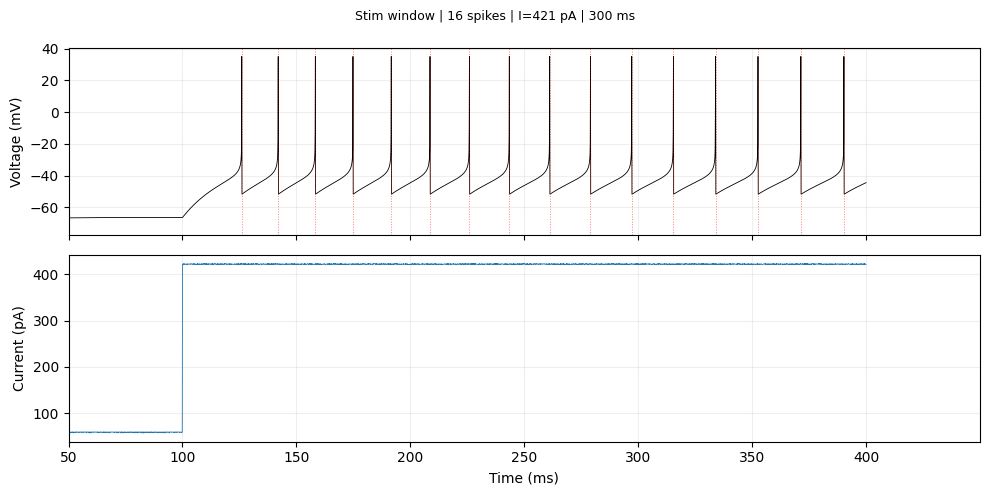

In [29]:
# --- Generate synthetic ground truth trace ---
SURROGATE_TYPE = "sigmoid"
SURROGATE_SLOPE = 5.0

sim_gt = simulate_with_current_trace(
    params=ground_truth_params,
    current_trace_pA=exp_cropped.current,
    dt_ms=exp_cropped.dt_ms,
    use_surrogate=True,
    surrogate_type=SURROGATE_TYPE,
    surrogate_slope=SURROGATE_SLOPE,
)
print(f"Ground truth: {sim_gt.n_spikes} spikes, {sim_gt.firing_rate_hz:.1f} Hz")

# Package as TraceData with spike peaks injected
n = len(exp_cropped.time)
voltage_gt = sim_gt.voltage[:n].copy()
SPIKE_PEAK_MV = 35.0
for st in sim_gt.spike_times:
    idx = int(st / exp_cropped.dt_ms)
    if 0 <= idx < len(voltage_gt):
        voltage_gt[idx] = SPIKE_PEAK_MV

data = TraceData(
    time=exp_cropped.time, voltage=voltage_gt, current=exp_cropped.current,
    dt_ms=exp_cropped.dt_ms, spike_times=sim_gt.spike_times,
    stim_start_idx=exp_cropped.stim_start_idx, stim_end_idx=exp_cropped.stim_end_idx,
    stim_current_pA=exp_cropped.stim_current_pA,
)
print(f"Synthetic TraceData: {data.n_samples} samples, {data.n_spikes} spikes")
print(f"Spike times: {data.spike_times.round(1)} ms")
trace_stim_window_plot(data);

In [30]:
# --- Perturbed initial parameters ---
PERTURBATION = 0.2
TRAINABLE_PARAMS = ["C_m", "g_L", "v_reset", "v_T", "E_L", "delta_T"]

def perturb_params(params, trainable, perturbation, key):
    perturbed = dict(params)
    keys = jr.split(key, len(trainable))
    for k, name in zip(keys, trainable):
        val = params[name]
        bounds = PARAM_BOUNDS[name]
        param_range = bounds.max - bounds.min
        noise = float(jr.uniform(k, minval=-perturbation, maxval=perturbation))
        perturbed[name] = bounds.clip(val + noise * param_range)
    return perturbed

initial_params = perturb_params(ground_truth_params, TRAINABLE_PARAMS, PERTURBATION, jr.PRNGKey(SEED))

print(f"{'Parameter':<12} {'Ground Truth':>12} {'Initial':>12} {'Error':>8}")
print("-" * 48)
for k in TRAINABLE_PARAMS:
    gt = ground_truth_params[k]
    init = initial_params[k]
    b = PARAM_BOUNDS[k]
    err = abs(init - gt) / (b.max - b.min) * 100
    print(f"{k:<12} {gt:>12.3f} {init:>12.3f} {err:>7.1f}%")

Parameter    Ground Truth      Initial    Error
------------------------------------------------
C_m               200.000      202.784     1.2%
g_L                10.000       10.729     9.1%
v_reset           -52.000      -49.659     6.7%
v_T               -45.000      -46.110     4.4%
E_L               -72.000      -67.613     9.7%
delta_T             3.000        2.348     3.4%


## 8. One-Shot Gradient Inspection (before training)

Check gradient magnitudes and directions at the initial parameters.

In [31]:
# Create cell and loss function
cell, data_stimuli, t_max, trainable_params = setup_trainable_cell(
    initial_params=initial_params,
    current_trace_pA=data.current,
    dt_ms=data.dt_ms,
    trainable_params=TRAINABLE_PARAMS,
    surrogate_type=SURROGATE_TYPE,
    surrogate_slope=SURROGATE_SLOPE,
)

exp_features = extract_experimental_features(
    voltage_trace=jnp.array(data.voltage),
    dt_ms=data.dt_ms,
    stim_duration_ms=data.stim_duration_ms,
    stim_end_index=data.stim_end_idx,
)

# loss_config = GuarinoLossConfig()
# loss_fn = make_loss_fn(
#     cell=cell, data_stimuli=data_stimuli, t_max=t_max, dt_ms=data.dt_ms,
#     exp_features=exp_features, stim_duration_ms=data.stim_duration_ms,
#     stim_end_index=data.stim_end_idx, loss_config=loss_config,
# )

# Build binary spike train from spike times (1.0 at spike timesteps, 0.0 elsewhere)
exp_spike_train = jnp.zeros(data.n_samples)
spike_indices = (data.spike_times / data.dt_ms).astype(int)
spike_indices = spike_indices[(spike_indices >= 0) & (spike_indices < data.n_samples)]
exp_spike_train = exp_spike_train.at[spike_indices].set(1.0)
print(f"Target spike train: {int(exp_spike_train.sum())} spikes in {data.n_samples} timesteps")

exp_voltage = jnp.array(data.voltage)

loss_config = VanRossumLossConfig(weight_subthreshold=0.1)
loss_fn = make_van_rossum_loss_fn(
    cell=cell, data_stimuli=data_stimuli, t_max=t_max, dt_ms=data.dt_ms,
    exp_spike_train=exp_spike_train,
    exp_voltage=exp_voltage,
    stim_end_index=data.stim_end_idx, loss_config=loss_config,
)

print("--- Gradient inspection at INITIAL params ---")
inspect_gradients(loss_fn, trainable_params)

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6
Target spike train: 16 spikes in 4000 timesteps
--- Gradient inspection at INITIAL params ---
Loss: 9.725616

Parameter           Value       Gradient       |Grad|  Direction
----------------------------------------------------------------
C_m              202.7840  -4.071333e+01 4.071333e+01   increase
g_L               10

## 9. Run Training with Gradient Diagnostics

In [32]:
# Re-create cell (training mutates state)
cell, data_stimuli, t_max, trainable_params = setup_trainable_cell(
    initial_params=initial_params,
    current_trace_pA=data.current,
    dt_ms=data.dt_ms,
    trainable_params=TRAINABLE_PARAMS,
    surrogate_type=SURROGATE_TYPE,
    surrogate_slope=SURROGATE_SLOPE,
)

# loss_fn = make_loss_fn(
#     cell=cell, data_stimuli=data_stimuli, t_max=t_max, dt_ms=data.dt_ms,
#     exp_features=exp_features, stim_duration_ms=data.stim_duration_ms,
#     stim_end_index=data.stim_end_idx, loss_config=loss_config,
# )

loss_fn = make_van_rossum_loss_fn(
    cell=cell, data_stimuli=data_stimuli, t_max=t_max, dt_ms=data.dt_ms,
    exp_spike_train=exp_spike_train,
    exp_voltage=exp_voltage,
    stim_end_index=data.stim_end_idx, loss_config=loss_config,
)

# Forward-pass observer: tracks spike count, VR distance, subthreshold MAE each epoch
fwd_fn = make_forward_fn(
    cell=cell, data_stimuli=data_stimuli, t_max=t_max, dt_ms=data.dt_ms,
    exp_spike_train=exp_spike_train, exp_voltage=exp_voltage,
    stim_end_index=data.stim_end_idx, loss_config=loss_config,
)

diag = train_with_diagnostics(
    loss_fn=loss_fn,
    trainable_params=trainable_params,
    n_epochs=100,
    optimizer_name="adam",
    learning_rate=0.001,
    use_param_transform=True,
    clip_to_bounds=False,
    print_every=10,
    forward_fn=fwd_fn,
    snapshot_every=1,
)

Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Added 1 recordings. See `.recordings` for details.
Number of newly added trainable parameters: 1. Total number of trainable parameters: 1
Number of newly added trainable parameters: 1. Total number of trainable parameters: 2
Number of newly added trainable parameters: 1. Total number of trainable parameters: 3
Number of newly added trainable parameters: 1. Total number of trainable parameters: 4
Number of newly added trainable parameters: 1. Total number of trainable parameters: 5
Number of newly added trainable parameters: 1. Total number of trainable parameters: 6


Epoch    0 | loss=9.725616 | grad_norm=8.65e+03 | spikes=28 vr=9.3242 sub=4.0140 | C_m=202.784, g_L=10.729, v_reset=-49.659, v_T=-46.110, E_L=-67.613, delta_T=2.348
Epoch   10 | loss=9.634356 | grad_norm=8.20e+07 | spikes=28 vr=9.2303 sub=4.0408 | C_m=202.934, g_L=10.738, v_reset=-49.678, v_T=-46.080, E_L=-67.624, delta_T=2.354
Epoch   20 | loss=9.190343 | grad_norm=6.35e+03 | spikes=27 vr=8.7922 sub=3.9810 | C_m=203.033, g_L=10.744, v_reset=-49.691, v_T=-46.060, E_L=-67.632, delta_T=2.358
Epoch   30 | loss=9.076127 | grad_norm=7.90e+02 | spikes=27 vr=8.6803 sub=3.9581 | C_m=203.071, g_L=10.746, v_reset=-49.696, v_T=-46.053, E_L=-67.635, delta_T=2.360
Epoch   40 | loss=9.043969 | grad_norm=1.42e-01 | spikes=27 vr=8.6486 sub=3.9532 | C_m=203.087, g_L=10.747, v_reset=-49.698, v_T=-46.050, E_L=-67.637, delta_T=2.361
Epoch   50 | loss=9.022302 | grad_norm=2.39e+03 | spikes=27 vr=8.6274 sub=3.9487 | C_m=203.092, g_L=10.748, v_reset=-49.699, v_T=-46.049, E_L=-67.637, delta_T=2.361
Epoch   60

## 10. Gradient Analysis

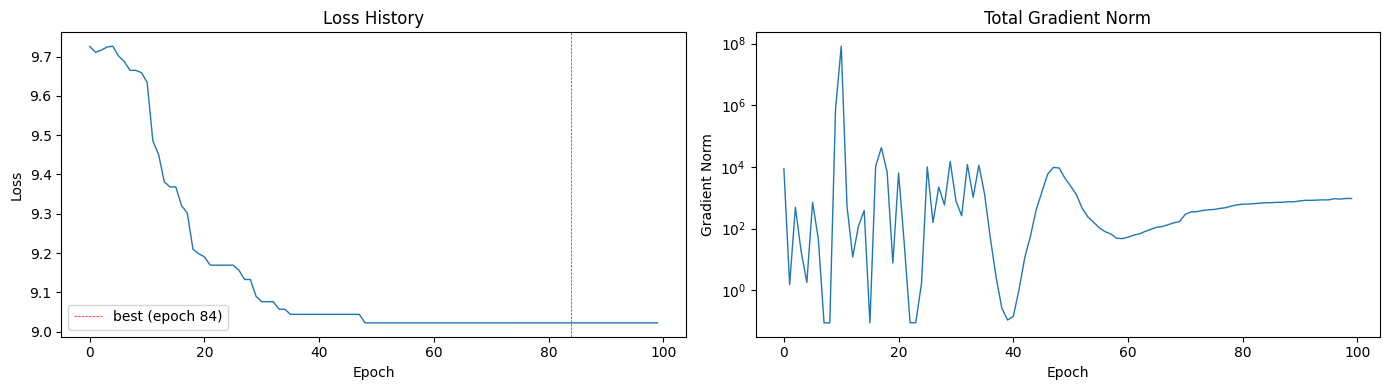

In [33]:
plot_loss_and_grad_norm(diag);

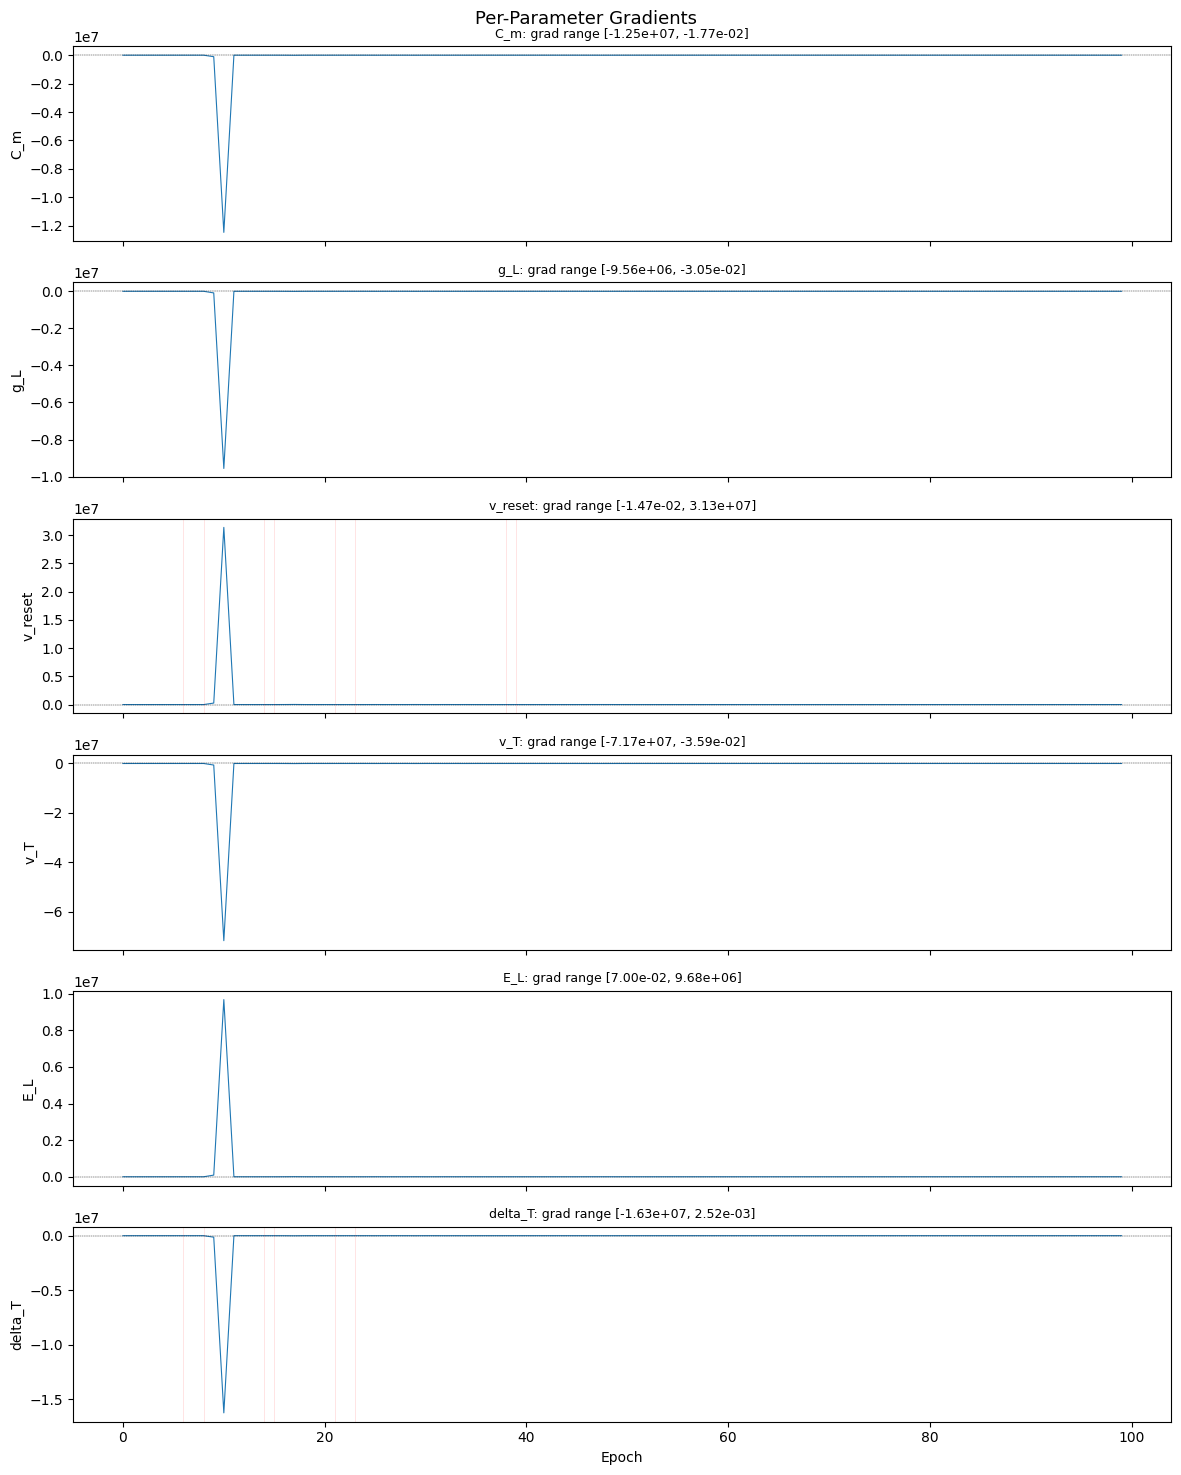

In [34]:
plot_per_param_gradients(diag);
# Red vertical lines = gradient sign changes (oscillation)

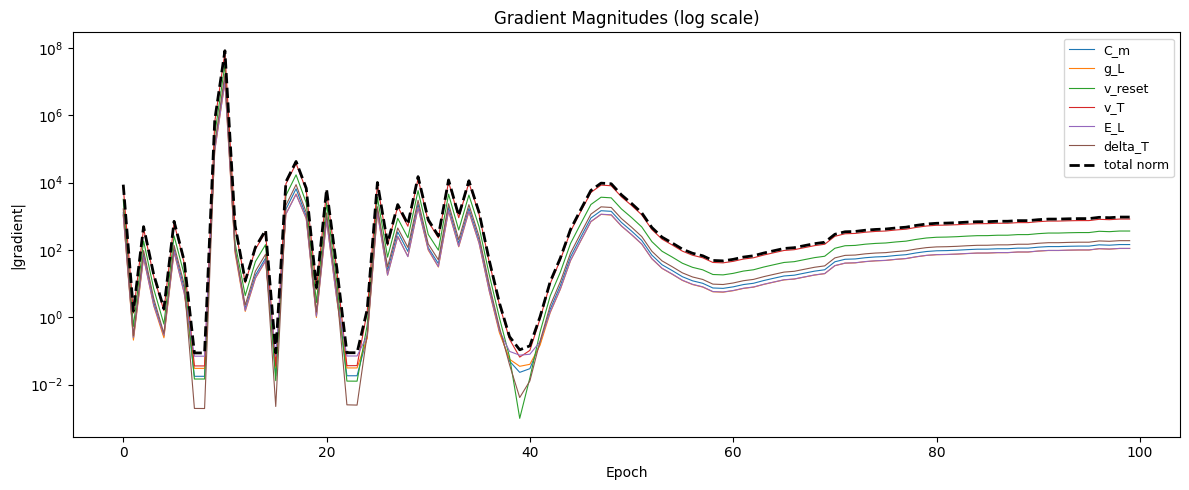

In [35]:
plot_gradient_magnitudes(diag);
# Shows which parameters dominate the total gradient norm

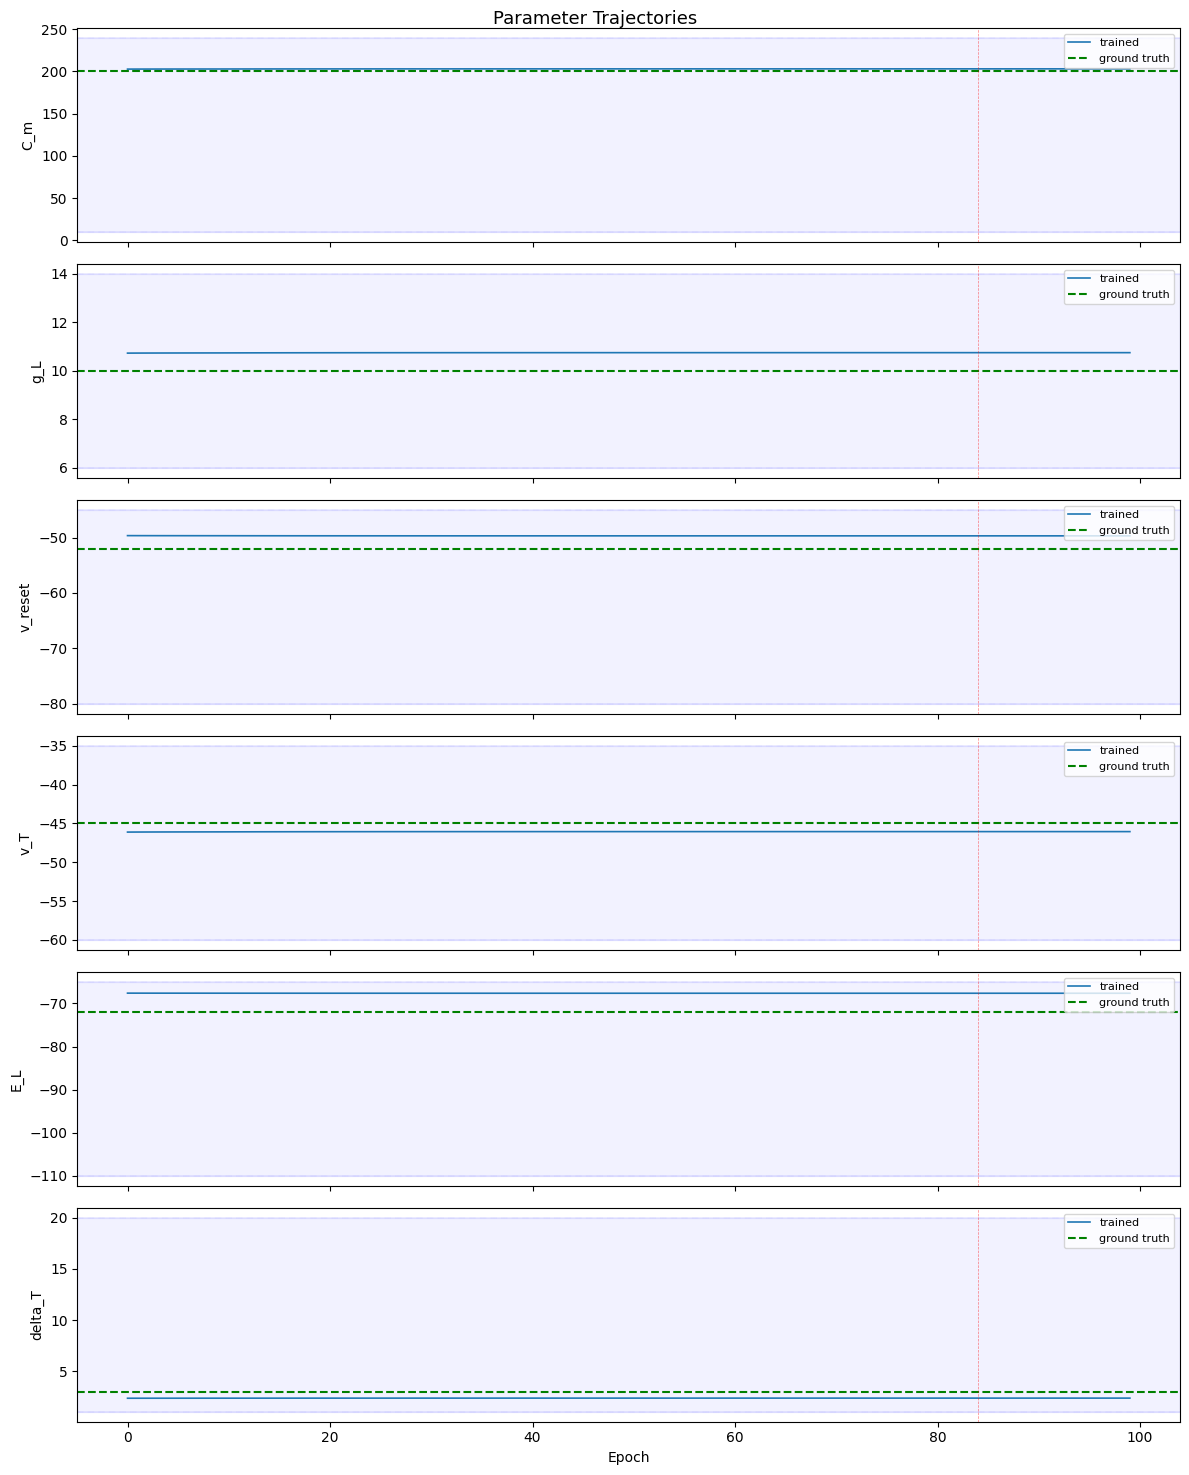

In [36]:
plot_param_trajectories(diag, ground_truth=ground_truth_params);
# Green dashed = ground truth, red dashed = best epoch, blue shading = param bounds

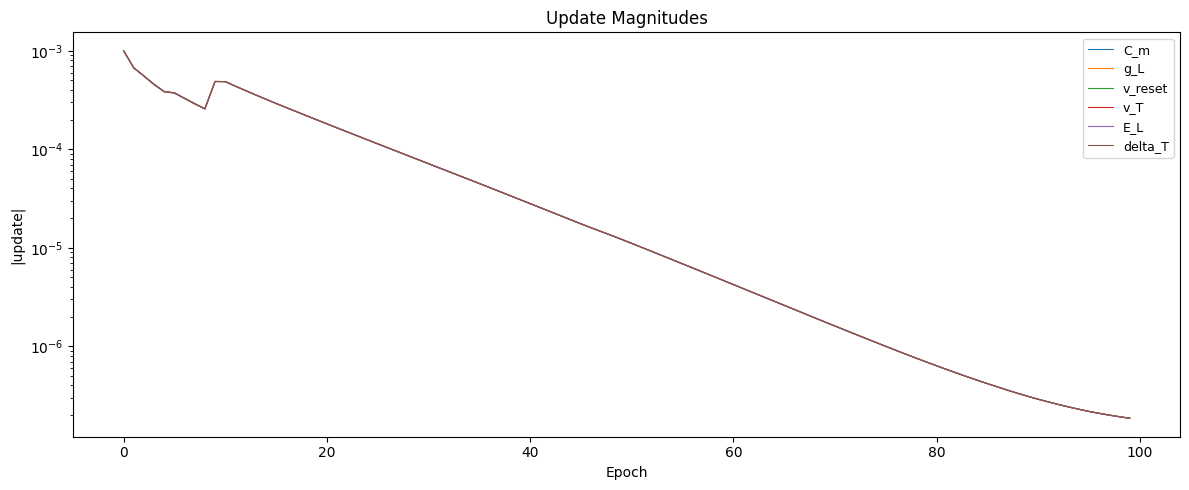

In [37]:
plot_update_magnitudes(diag);
# Shows actual step sizes (after Adam momentum/scaling)

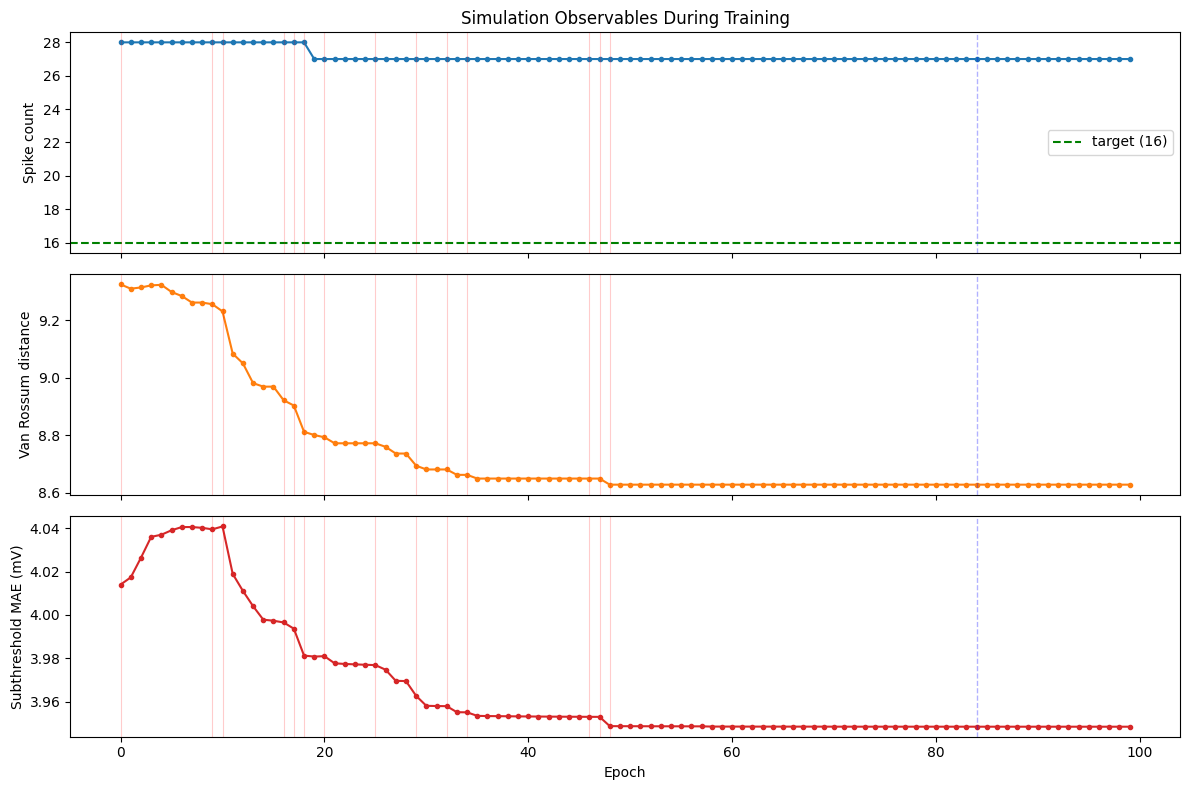

In [38]:
# --- Simulation snapshot analysis ---
if diag.snapshots:
    epochs_snap = [s["epoch"] for s in diag.snapshots]
    n_spikes_hist = [s["n_spikes"] for s in diag.snapshots]
    vr_hist = [s["vr_distance"] for s in diag.snapshots]
    sub_hist = [s["sub_mae"] for s in diag.snapshots]

    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

    # Spike count over training
    axes[0].plot(epochs_snap, n_spikes_hist, "o-", markersize=3)
    axes[0].axhline(data.n_spikes, color="green", linestyle="--", label=f"target ({data.n_spikes})")
    axes[0].set_ylabel("Spike count")
    axes[0].legend()
    axes[0].set_title("Simulation Observables During Training")

    # Van Rossum distance
    axes[1].plot(epochs_snap, vr_hist, "o-", markersize=3, color="tab:orange")
    axes[1].set_ylabel("Van Rossum distance")

    # Subthreshold MAE
    axes[2].plot(epochs_snap, sub_hist, "o-", markersize=3, color="tab:red")
    axes[2].set_ylabel("Subthreshold MAE (mV)")
    axes[2].set_xlabel("Epoch")

    # Mark gradient spikes (epochs where grad_norm > 10x median)
    gn = np.array(diag.total_grad_norm)
    median_gn = np.median(gn)
    spike_epochs = np.where(gn > 10 * median_gn)[0]
    for ax in axes:
        for se in spike_epochs:
            ax.axvline(se, color="red", alpha=0.2, linewidth=0.8)
        ax.axvline(diag.best_epoch, color="blue", alpha=0.3, linewidth=1, linestyle="--")

    fig.tight_layout()
else:
    print("No snapshots recorded (forward_fn was not set).")

## 11. Loss Decomposition

Which Guarino features are driving the loss at each epoch?

In [39]:
# Evaluate per-feature loss at best params
loss_fn_decomposed = make_loss_fn_decomposed(
    cell=cell, data_stimuli=data_stimuli, t_max=t_max, dt_ms=data.dt_ms,
    exp_features=exp_features, stim_duration_ms=data.stim_duration_ms,
    stim_end_index=data.stim_end_idx, loss_config=loss_config,
)

# At initial params
from ADoptEX.training.trainer import make_initial_trainable_params
initial_tp = make_initial_trainable_params(cell, initial_params)
losses_init, feats_init = loss_fn_decomposed(initial_tp)

# At best params
losses_best, feats_best = loss_fn_decomposed(diag.best_params)

print("Per-feature loss decomposition:")
print(f"{'Feature':<18} {'Initial':>10} {'Best':>10} {'Change':>10}")
print("-" * 50)
total_init, total_best = 0, 0
for feat_name in losses_init:
    li = losses_init[feat_name]
    lb = losses_best[feat_name]
    total_init += li
    total_best += lb
    arrow = "v" if lb < li else "^" if lb > li else "="
    print(f"{feat_name:<18} {li:>10.4f} {lb:>10.4f} {arrow:>4} {lb - li:>+.4f}")
print("-" * 50)
print(f"{'TOTAL':<18} {total_init:>10.4f} {total_best:>10.4f}")

# Bar chart
fig, ax = plt.subplots(figsize=(10, 4))
names = list(losses_init.keys())
x = np.arange(len(names))
w = 0.35
ax.bar(x - w/2, [losses_init[n] for n in names], w, label="Initial", alpha=0.7)
ax.bar(x + w/2, [losses_best[n] for n in names], w, label="Best", alpha=0.7)
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=45, ha="right")
ax.set_ylabel("Loss contribution")
ax.set_title("Per-Feature Loss Decomposition")
ax.legend()
fig.tight_layout();

AttributeError: 'VanRossumLossConfig' object has no attribute 'epsilon'

## 12. Evaluate Final Result

In [ ]:
# Simulate with best parameters
best_params_dict = dict(initial_params)
best_params_dict.update(diag.get_best_params_dict())

sim_best = simulate_with_current_trace(
    params=best_params_dict,
    current_trace_pA=data.current,
    dt_ms=data.dt_ms,
    use_surrogate=True,
    surrogate_type=SURROGATE_TYPE,
    surrogate_slope=SURROGATE_SLOPE,
)

print(f"Best epoch: {diag.best_epoch}")
print(f"Spikes: {sim_best.n_spikes} (target: {data.n_spikes})")

if sim_best.n_spikes > 0 and data.n_spikes > 0:
    cf = coincidence_factor(data.spike_times, sim_best.spike_times, data.stim_duration_ms, delta_ms=4)
    print(f"Gamma = {cf.gamma:.3f}")

# Parameter recovery table
print(f"\n{'Parameter':<12} {'Ground Truth':>12} {'Initial':>12} {'Best':>12} {'Error':>8}")
print("-" * 60)
for k in TRAINABLE_PARAMS:
    gt = ground_truth_params[k]
    init = initial_params[k]
    best = best_params_dict[k]
    b = PARAM_BOUNDS[k]
    err_init = abs(init - gt) / (b.max - b.min) * 100
    err_best = abs(best - gt) / (b.max - b.min) * 100
    print(f"{k:<12} {gt:>12.3f} {init:>12.3f} {best:>12.3f} {err_init:>4.1f}%->{err_best:.1f}%")

fit_comparison_plot(data, sim_best);